In [120]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from collections import defaultdict
from tqdm import tqdm

In [105]:
G = nx.DiGraph()
nodes = [chr(x) for x in range(ord("a"),ord("z"))]
for n in nodes:
    npeers = 5
    neighbours = [p for p in random.sample(nodes,3) if p != n]
    weights = np.array([random.random()**2 for _ in neighbours])
    weights = weights / weights.sum()
    #print(weights)
    for p, w in zip(neighbours, weights):
        G.add_edge(n,p, weight=w)
    #break

{('a', 'r'): '0.36', ('a', 'c'): '0.32', ('a', 'i'): '0.32', ('r', 'f'): '0.00', ('r', 'v'): '0.01', ('r', 'g'): '0.98', ('c', 'y'): '0.02', ('c', 'p'): '0.85', ('c', 'o'): '0.13', ('i', 'r'): '0.55', ('i', 'l'): '0.08', ('i', 'c'): '0.36', ('b', 'h'): '0.20', ('b', 'r'): '0.21', ('b', 'x'): '0.59', ('h', 'n'): '0.32', ('h', 'o'): '0.00', ('h', 't'): '0.68', ('x', 'k'): '0.99', ('x', 'u'): '0.01', ('y', 'r'): '0.00', ('y', 'w'): '0.00', ('y', 'p'): '0.99', ('p', 'y'): '0.66', ('p', 'e'): '0.34', ('p', 'f'): '0.00', ('o', 'y'): '0.61', ('o', 'j'): '0.01', ('o', 'x'): '0.38', ('d', 'x'): '0.02', ('d', 'c'): '0.02', ('d', 'i'): '0.96', ('e', 'y'): '0.04', ('e', 'c'): '0.68', ('e', 's'): '0.28', ('s', 'e'): '0.81', ('s', 'o'): '0.01', ('s', 'f'): '0.18', ('f', 'm'): '0.01', ('f', 'l'): '0.99', ('m', 'v'): '0.08', ('m', 'b'): '0.49', ('m', 'i'): '0.43', ('l', 'e'): '0.04', ('l', 'o'): '0.96', ('g', 'd'): '0.76', ('g', 'l'): '0.02', ('g', 'x'): '0.22', ('n', 's'): '0.05', ('n', 'c'): '0.46',

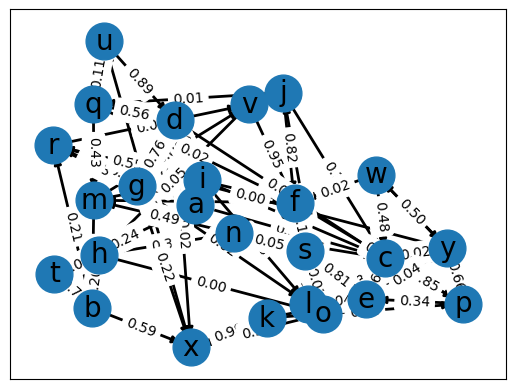

In [106]:
pos = nx.spring_layout(G, seed=23)  # positions for all nodes - seed for reproducibility
nx.draw_networkx_nodes(G, pos, node_size=700),
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=2),
nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
edge_labels = nx.get_edge_attributes(G, "weight")
#print(edge_labels)
format_labels = {k:"%.2f"%v for k,v in edge_labels.items()}
print(format_labels)
nx.draw_networkx_edge_labels(G, pos, format_labels)
plt.show()

In [143]:
packets_in = {}
packets_out = defaultdict(int)
packets_per_node = 50
for n in G.nodes:
    packets_in[n] = packets_per_node
print(packets_in)
for epoch in tqdm(range(30)):
    for n in G.nodes:
        #print(n)
        neighbours = list(G.successors(n))
        #print(neighbours)
        weights = [G.edges[(n,neigh)]["weight"] for neigh in neighbours]
        #print(weights)
        for inp in range(packets_in[n]):
            next_hop = random.choices(neighbours, weights=weights, k=1)[0]
            packets_out[next_hop] += 1
    #print(packets_out)
    packets_in = packets_out
    packets_out = defaultdict(int)
    #break
print(packets_in)

{'a': 50, 'r': 50, 'c': 50, 'i': 50, 'b': 50, 'h': 50, 'x': 50, 'y': 50, 'p': 50, 'o': 50, 'd': 50, 'e': 50, 's': 50, 'f': 50, 'm': 50, 'l': 50, 'g': 50, 'n': 50, 't': 50, 'j': 50, 'q': 50, 'k': 50, 'v': 50, 'u': 50, 'w': 50}


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 199.41it/s]

defaultdict(<class 'int'>, {'p': 445, 'o': 33, 'y': 329, 'c': 114, 'k': 14, 'w': 3, 'r': 2, 'e': 216, 'f': 12, 'x': 13, 'i': 1, 's': 54, 'l': 13, 'd': 1})


In [145]:
nx.diameter(G)

7

In [139]:
ranked = nx.pagerank(G, weight='weight', alpha=1.0)

In [134]:
nodes = list(G.nodes())
A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')

In [135]:
eigvals, eigvecs = np.linalg.eig(A.T)

# Find eigenvalue closest to 1
idx = np.argmin(np.abs(eigvals - 1))

steady_state = np.real(eigvecs[:, idx])
steady_state /= steady_state.sum()

In [136]:
steady_state_dict = dict(zip(nodes, steady_state))
print(steady_state_dict)

{'a': np.float64(1.7765285737533613e-06), 'r': np.float64(0.0013262580072462774), 'c': np.float64(0.11357930793469116), 'i': np.float64(0.0011042431883774113), 'b': np.float64(4.79958511334182e-05), 'h': np.float64(1.084920668889805e-05), 'x': np.float64(0.00947247901671916), 'y': np.float64(0.25502289507474013), 'p': np.float64(0.3496986853370896), 'o': np.float64(0.023961849659769323), 'd': np.float64(0.001110530138603759), 'e': np.float64(0.16673364000920005), 's': np.float64(0.04749718431310852), 'f': np.float64(0.009143060837930386), 'm': np.float64(8.728406610341797e-05), 'l': np.float64(0.009178021860645664), 'g': np.float64(0.001305927236827145), 'n': np.float64(3.4451808795032513e-06), 't': np.float64(7.3769711432795055e-06), 'j': np.float64(0.00013841701347257898), 'q': np.float64(1.3842413359277407e-05), 'k': np.float64(0.009354053266282305), 'v': np.float64(2.5613426766299746e-05), 'u': np.float64(0.00011842575043685048), 'w': np.float64(0.0010568377102119716)}


In [114]:
packets_in

defaultdict(int,
            {'i': 2486,
             'r': 1375,
             'c': 6260,
             'g': 1459,
             'v': 26,
             'f': 522,
             'p': 15972,
             'o': 1620,
             'y': 10642,
             'l': 625,
             'x': 1864,
             'h': 81,
             't': 81,
             'n': 31,
             'k': 3341,
             'u': 53,
             'w': 35,
             'e': 9913,
             'j': 15,
             's': 2346,
             'm': 103,
             'b': 308,
             'd': 3258,
             'a': 80,
             'q': 4})

In [144]:
for n,p in packets_in.items():
    walk = p/sum(packets_in.values())
    print(n, walk, ranked[n], walk/ranked[n])
    #print(n, walk, steady_state_dict[n], walk/ranked[n])
    

p 0.356 0.34968880190524754 1.0180480417455935
o 0.0264 0.023962758393948888 1.1017095597252513
y 0.2632 0.2550141782166525 1.0320994771372791
c 0.0912 0.11357974271496385 0.8029600861913612
k 0.0112 0.009355556198363103 1.1971495614509386
w 0.0024 0.0010567917955439027 2.271024444095711
r 0.0016 0.0013287908618800095 1.2041021999024561
e 0.1728 0.16672958687474895 1.0364087336809111
f 0.0096 0.00914286729106868 1.0499988345426248
x 0.0104 0.009474221039778694 1.097715575384436
i 0.0008 0.0011084247107116549 0.721745006466309
s 0.0432 0.04749664061646581 0.9095380102529551
l 0.0104 0.009178279154447312 1.1331100116911028
d 0.0008 0.0011150763764070837 0.7174396453251934


In [111]:
sum(ranked.values())

0.9999999999999992

In [132]:
list(G.predecessors("r"))

['a', 'b', 'i', 'y']